# Inspect the KEGG ORA tensor — per-drug (perturbation × pathway) heatmaps

Loads `PathwayORA/KEGG/KEGG_ORA_tensor.h5` (built by notebook 16) and
renders one heatmap per drug context. Each heatmap is the `-log10(q_bh)`
matrix for that drug, sliced from the 3D tensor:

```
tensor.shape == (n_drugs, n_perturbations, n_pathways)  # (16, 2447, 568)
```

The full matrix per drug is 2,447 × 568 — too large to render as-is, so for
each drug we filter to the **active sub-matrix**: perturbations that hit at
least one pathway at `q_bh < 0.1`, and pathways that are hit by at least
`MIN_PERTS_PER_PATHWAY` perturbations. Rows and columns are clustered for
readability.

In [16]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scanpy as sc

In [26]:
a=sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak_Pathways/Romidepsin.h5ad")

In [29]:
a.X.shape

(1577934, 7589)

## Paths and parameters

In [8]:
PROJECT_DIR = Path('/home/beraslan/Projects/ChemoGeneticScreens')
H5_PATH     = PROJECT_DIR / 'PathwayORA' / 'KEGG' / 'KEGG_ORA_tensor.h5'

# Visualization filters
Q_THRESHOLD            = 0.05   # cell counts as 'significant' below this q
MIN_PERTS_PER_PATHWAY  = 10    # keep pathways enriched in ≥ this many perts (per drug)
MIN_PATHWAYS_PER_PERT  = 1      # keep perts that hit ≥ this many pathways (per drug)
VMAX                   = 5.0    # color scale cap; -log10(1e-5) = 5
FIGSIZE                = (14, 10)

## Load the tensor and axis labels

In [9]:
with h5py.File(H5_PATH, 'r') as h:
    neg_log10_q = h['neg_log10_q'][:]                                    # (D, P, K)
    q_value     = h['q_value'][:]
    drugs       = [s.decode() for s in h['drugs'][:]]
    perts       = [s.decode() for s in h['perturbations'][:]]
    pathways    = [s.decode() for s in h['pathways'][:]]

n_drugs, n_perts, n_paths = neg_log10_q.shape
print(f'Tensor shape: ({n_drugs} drugs, {n_perts} perturbations, {n_paths} pathways)')
print(f'Drugs: {drugs}')

Tensor shape: (16 drugs, 2447 perturbations, 568 pathways)
Drugs: ['AR-A014418', 'AZD4573', 'Bisindolylmaleimide-I', 'CHIR-98014', 'DG-172', 'DMSO_round2', 'DMSO_round2_batch2', 'JTE-607', 'LDN-193189', 'LY2090314', 'Lexibulin', 'NSC95397', 'PP121', 'Romidepsin', 'Stattic', 'VX-11e']


## Per-drug slicing + active-submatrix helpers

`get_drug_matrix` returns the full `(perturbation × pathway)` DataFrame of
`-log10(q_bh)` for one drug; `active_submatrix` filters it down to the rows
and columns with enough significant cells to be worth plotting.

In [10]:
def get_drug_matrix(drug, score=neg_log10_q):
    d_idx = drugs.index(drug)
    return pd.DataFrame(score[d_idx], index=perts, columns=pathways)


def active_submatrix(df, q_df, q_thr=Q_THRESHOLD,
                     min_perts_per_pathway=MIN_PERTS_PER_PATHWAY,
                     min_pathways_per_pert=MIN_PATHWAYS_PER_PERT):
    """Filter rows/cols by sig-cell count, drop all-NaN rows/cols."""
    sig = q_df < q_thr
    keep_paths = sig.sum(axis=0) >= min_perts_per_pathway
    keep_perts = sig.sum(axis=1) >= min_pathways_per_pert
    sub = df.loc[keep_perts, keep_paths]
    return sub


def cluster_order(values):
    """Return row/col order from hierarchical clustering on a NaN-safe copy."""
    from scipy.spatial.distance import pdist
    from scipy.cluster.hierarchy import linkage, leaves_list
    arr = np.nan_to_num(values, nan=0.0)
    if arr.shape[0] < 2:
        return np.arange(arr.shape[0])
    Z = linkage(pdist(arr, metric='euclidean'), method='average')
    return leaves_list(Z)


def plot_drug_heatmap(drug, ax=None, vmax=VMAX, cluster=True):
    score_df = get_drug_matrix(drug, neg_log10_q)
    q_df     = get_drug_matrix(drug, q_value)
    sub      = active_submatrix(score_df, q_df)
    if sub.shape[0] == 0 or sub.shape[1] == 0:
        if ax is None:
            fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.text(0.5, 0.5, f'no significant cells\nfor {drug}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return ax, sub
    if cluster:
        row_order = cluster_order(sub.values)
        col_order = cluster_order(sub.values.T)
        sub = sub.iloc[row_order, col_order]
    if ax is None:
        fig, ax = plt.subplots(figsize=FIGSIZE)
    sns.heatmap(
        sub,
        ax=ax,
        cmap='magma_r',
        vmin=0, vmax=vmax,
        cbar_kws={'label': '-log10(q_bh)'},
        xticklabels=False,
        yticklabels=(sub.shape[0] <= 60),
    )
    ax.set_title(f'{drug}  —  {sub.shape[0]} perts × {sub.shape[1]} pathways')
    ax.set_xlabel('KEGG pathways (clustered)')
    ax.set_ylabel('Perturbations (clustered)')
    return ax, sub

## Per-drug summary: how many cells are significant

Helps pick where to focus before plotting all 16.

In [11]:
summary = []
for d_idx, drug in enumerate(drugs):
    q = q_value[d_idx]
    finite = np.isfinite(q)
    sig = (q < Q_THRESHOLD)
    summary.append({
        'drug':           drug,
        'tested_cells':   int(finite.sum()),
        'sig_cells':      int(sig.sum()),
        'pct_sig':        100.0 * sig.sum() / max(finite.sum(), 1),
        'active_perts':   int((sig.sum(axis=1) >= MIN_PATHWAYS_PER_PERT).sum()),
        'active_paths':   int((sig.sum(axis=0) >= MIN_PERTS_PER_PATHWAY).sum()),
    })
summary_df = pd.DataFrame(summary).sort_values('pct_sig', ascending=False)
print(summary_df.to_string(index=False))

                 drug  tested_cells  sig_cells  pct_sig  active_perts  active_paths
              JTE-607        560048      10840 1.935548           598           121
               DG-172        543008       9214 1.696844           538           125
           AR-A014418        550392       8503 1.544899           482           121
            Lexibulin        526536       6671 1.266960           483           102
              Stattic        511768       5973 1.167130           478            99
           Romidepsin        516312       5914 1.145431           489            97
             NSC95397        499840       5395 1.079345           485            90
              AZD4573        484504       4646 0.958919           426            92
                PP121        477120       4419 0.926182           424            87
Bisindolylmaleimide-I        499840       4593 0.918894           450            83
           LDN-193189        523128       4788 0.915264           464       

## Heatmap per drug

One large per-drug heatmap. Both axes are clustered. Pathways with too few
significant perturbations are dropped, and perturbations that don't hit any
pathway are dropped — otherwise the rendering would be a sea of NaN.

In [12]:
# for drug in drugs:
#     fig, ax = plt.subplots(figsize=FIGSIZE)
#     plot_drug_heatmap(drug, ax=ax)
#     plt.tight_layout()
#     plt.show()

## Compact 2 × 8 grid (all drugs at once)

Same data, smaller panels arranged as 2 rows × 8 columns — useful for a
quick cross-context comparison. All panels share the same row (perturbation)
and column (pathway) order, computed once on the across-drug mean of
`-log10(q_bh)`. NaN cells (perturbations missing from a drug's screen, or
skipped due to <5 sig DE genes in that drug) are shown in lightgrey.

The filter used here is the same "perturbation hits ≥ `MIN_PATHWAYS_PER_PERT`
pathways in some single drug" criterion as the saved reduced tensor, so the
perturbation count matches.

Shared grid axes: 941 perts × 173 pathways (union of per-drug active sets)


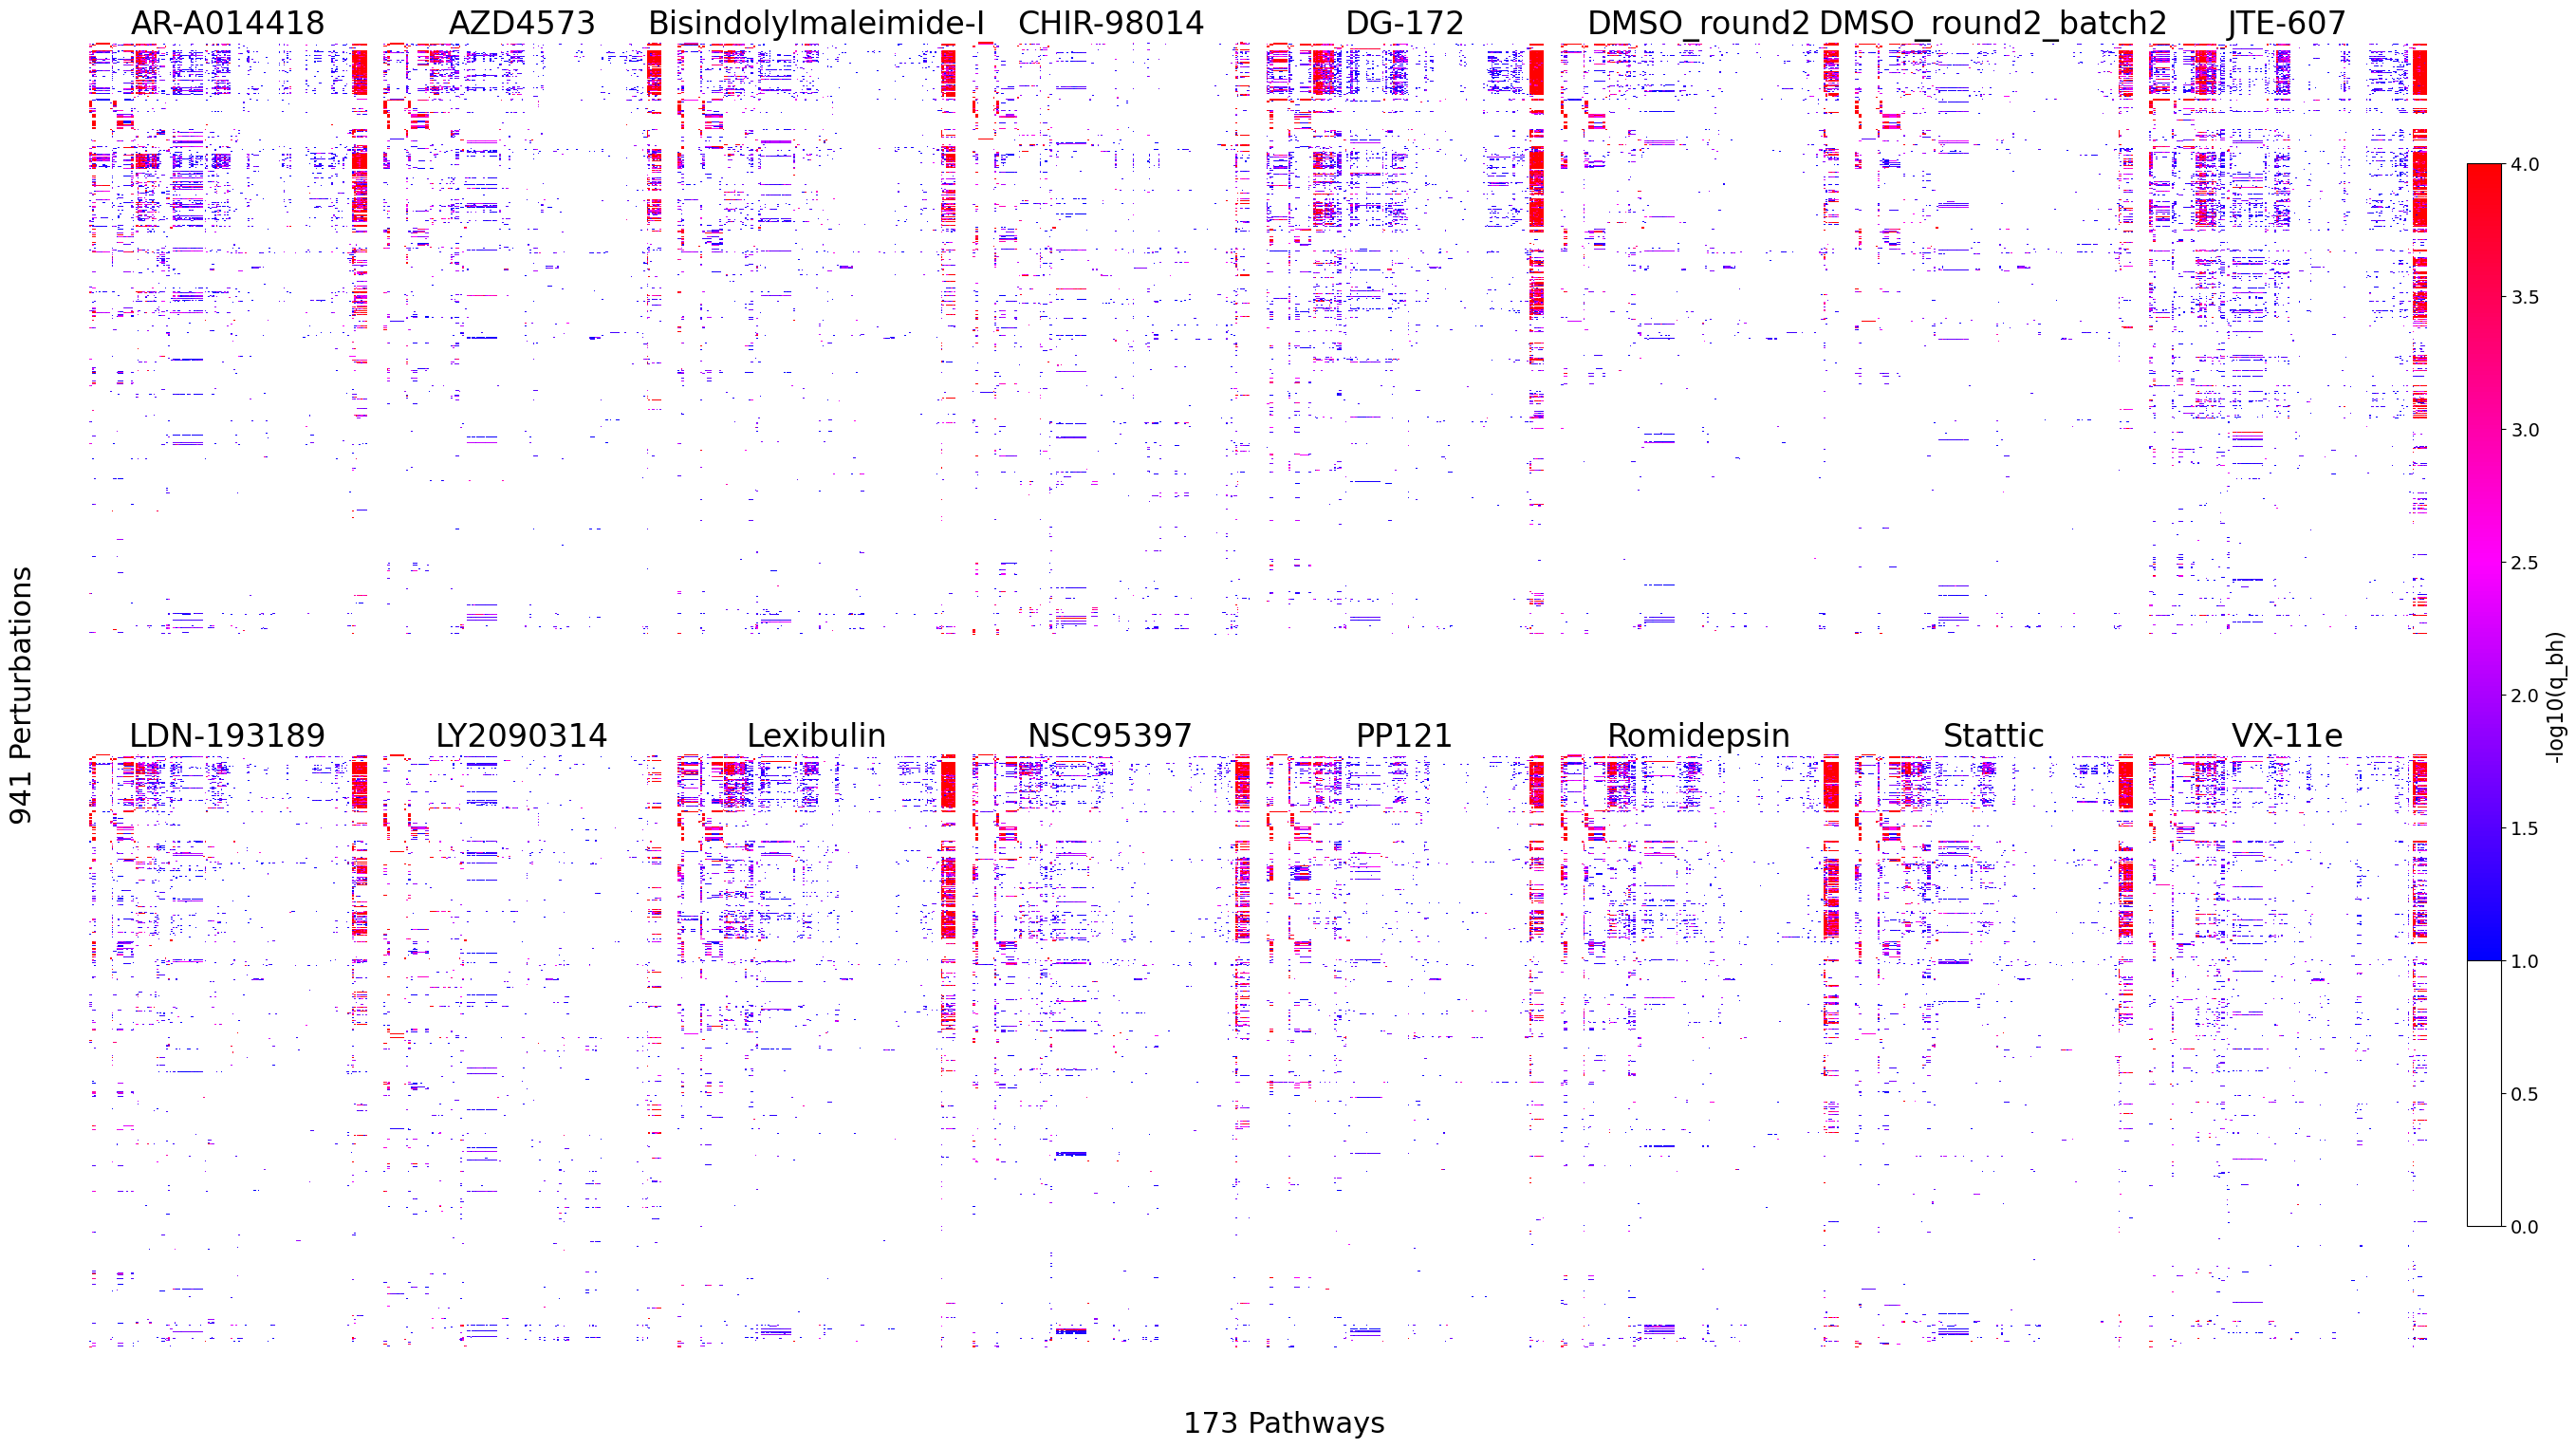

In [13]:
from matplotlib.colors import LinearSegmentedColormap

# Build a global active sub-tensor so all panels share the same axes.
sig = q_value < Q_THRESHOLD                               # (D, P, K) bool

pathway_max_perts_any_drug = sig.sum(axis=1).max(axis=0)
g_keep_paths_idx = np.where(pathway_max_perts_any_drug >= MIN_PERTS_PER_PATHWAY)[0]

sig_kept = sig[:, :, g_keep_paths_idx]
pert_max_paths_any_drug = sig_kept.sum(axis=2).max(axis=0)
g_keep_perts_idx = np.where(pert_max_paths_any_drug >= MIN_PATHWAYS_PER_PERT)[0]

mean_score = np.nanmean(
    neg_log10_q[:, g_keep_perts_idx, :][:, :, g_keep_paths_idx],
    axis=0,
)
g_row_order = cluster_order(np.nan_to_num(mean_score,   nan=0.0))
g_col_order = cluster_order(np.nan_to_num(mean_score.T, nan=0.0))

ordered_perts = [perts[i]    for i in g_keep_perts_idx[g_row_order]]
ordered_paths = [pathways[j] for j in g_keep_paths_idx[g_col_order]]

print(f'Shared grid axes: {len(ordered_perts)} perts × {len(ordered_paths)} pathways '
      f'(union of per-drug active sets)')

# Continuous colormap: white below the FDR threshold (-log10(q) < 1, i.e. q ≥ 0.1),
# then a smooth blue → magenta → red gradient for significant cells.
NA_COLOR  = 'white'
GRID_VMAX = 4
THR       = 1.0                                    # -log10(0.1) = 1
thr_pos   = THR / GRID_VMAX                         # = 0.25 when GRID_VMAX = 4

cmap_grid = LinearSegmentedColormap.from_list(
    'wbgr',
    [(0.0,                    'white'),
     (max(thr_pos - 1e-3, 0), 'white'),             # white plateau ends just below threshold
     (thr_pos,                'blue'),               # sharp jump to blue at the threshold
     ((thr_pos + 1.0) / 2,    'magenta'),            # mid of significant range
     (1.0,                    'red')],
    N=256,
)
cmap_grid.set_bad(NA_COLOR)

# Font sizes
TITLE_FS = 24      # per-panel drug names
SUP_FS   = 22      # whole-figure axis labels
CBAR_FS  = 16

fig, axes = plt.subplots(2, 8, figsize=(28, 16))
fig.subplots_adjust(left=0.05, right=0.93, top=0.93, bottom=0.07,
                    wspace=0.06, hspace=0.20)

for ax, drug in zip(axes.flat, drugs):
    d_idx = drugs.index(drug)
    sub = pd.DataFrame(
        neg_log10_q[d_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)],
        index=[perts[i]    for i in g_keep_perts_idx],
        columns=[pathways[j] for j in g_keep_paths_idx],
    ).loc[ordered_perts, ordered_paths]

    sns.heatmap(
        sub, ax=ax,
        cmap=cmap_grid, vmin=0, vmax=GRID_VMAX,
        cbar=False,
        xticklabels=False, yticklabels=False,
    )
    ax.set_title(drug, fontsize=TITLE_FS)
    ax.set_facecolor(NA_COLOR)

# Whole-figure axis labels
fig.supxlabel(f'{len(ordered_paths):,} Pathways',     fontsize=SUP_FS)
fig.supylabel(f'{len(ordered_perts):,} Perturbations', fontsize=SUP_FS)

# Single shared continuous colorbar; horizontal line marks the FDR=0.1 threshold
cbar_ax = fig.add_axes([0.945, 0.15, 0.013, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap_grid,
                           norm=plt.Normalize(vmin=0, vmax=GRID_VMAX))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(q_bh)', fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=CBAR_FS - 2)
cbar.ax.axhline(THR, color='black', lw=0.8)

plt.show()

## Drug − DMSO  binary-significance difference  (batch-matched)

Same 14-drug × pathway × perturbation tensor as the grid above, but binarised
(`q_bh < 0.10` → 1, else 0). For each drug we subtract its **same-batch DMSO**
from the drug's binary matrix so each cell is in `{-1, 0, +1}`:

- **+1** (red): drug-only significant — drug *induces* the (pert × pathway) hit that DMSO doesn't have
- **−1** (blue): DMSO-only significant — drug *suppresses* a constitutive hit
- **0** (white): both sig or both not sig — no drug-specific effect

Batch1 drugs are referenced against `DMSO_round2`; batch2 against `DMSO_round2_batch2`.

/tmp/ipykernel_272788/3433883620.py:55: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color='white', edgecolor='gray', label='0  agree (both sig or both not)'),


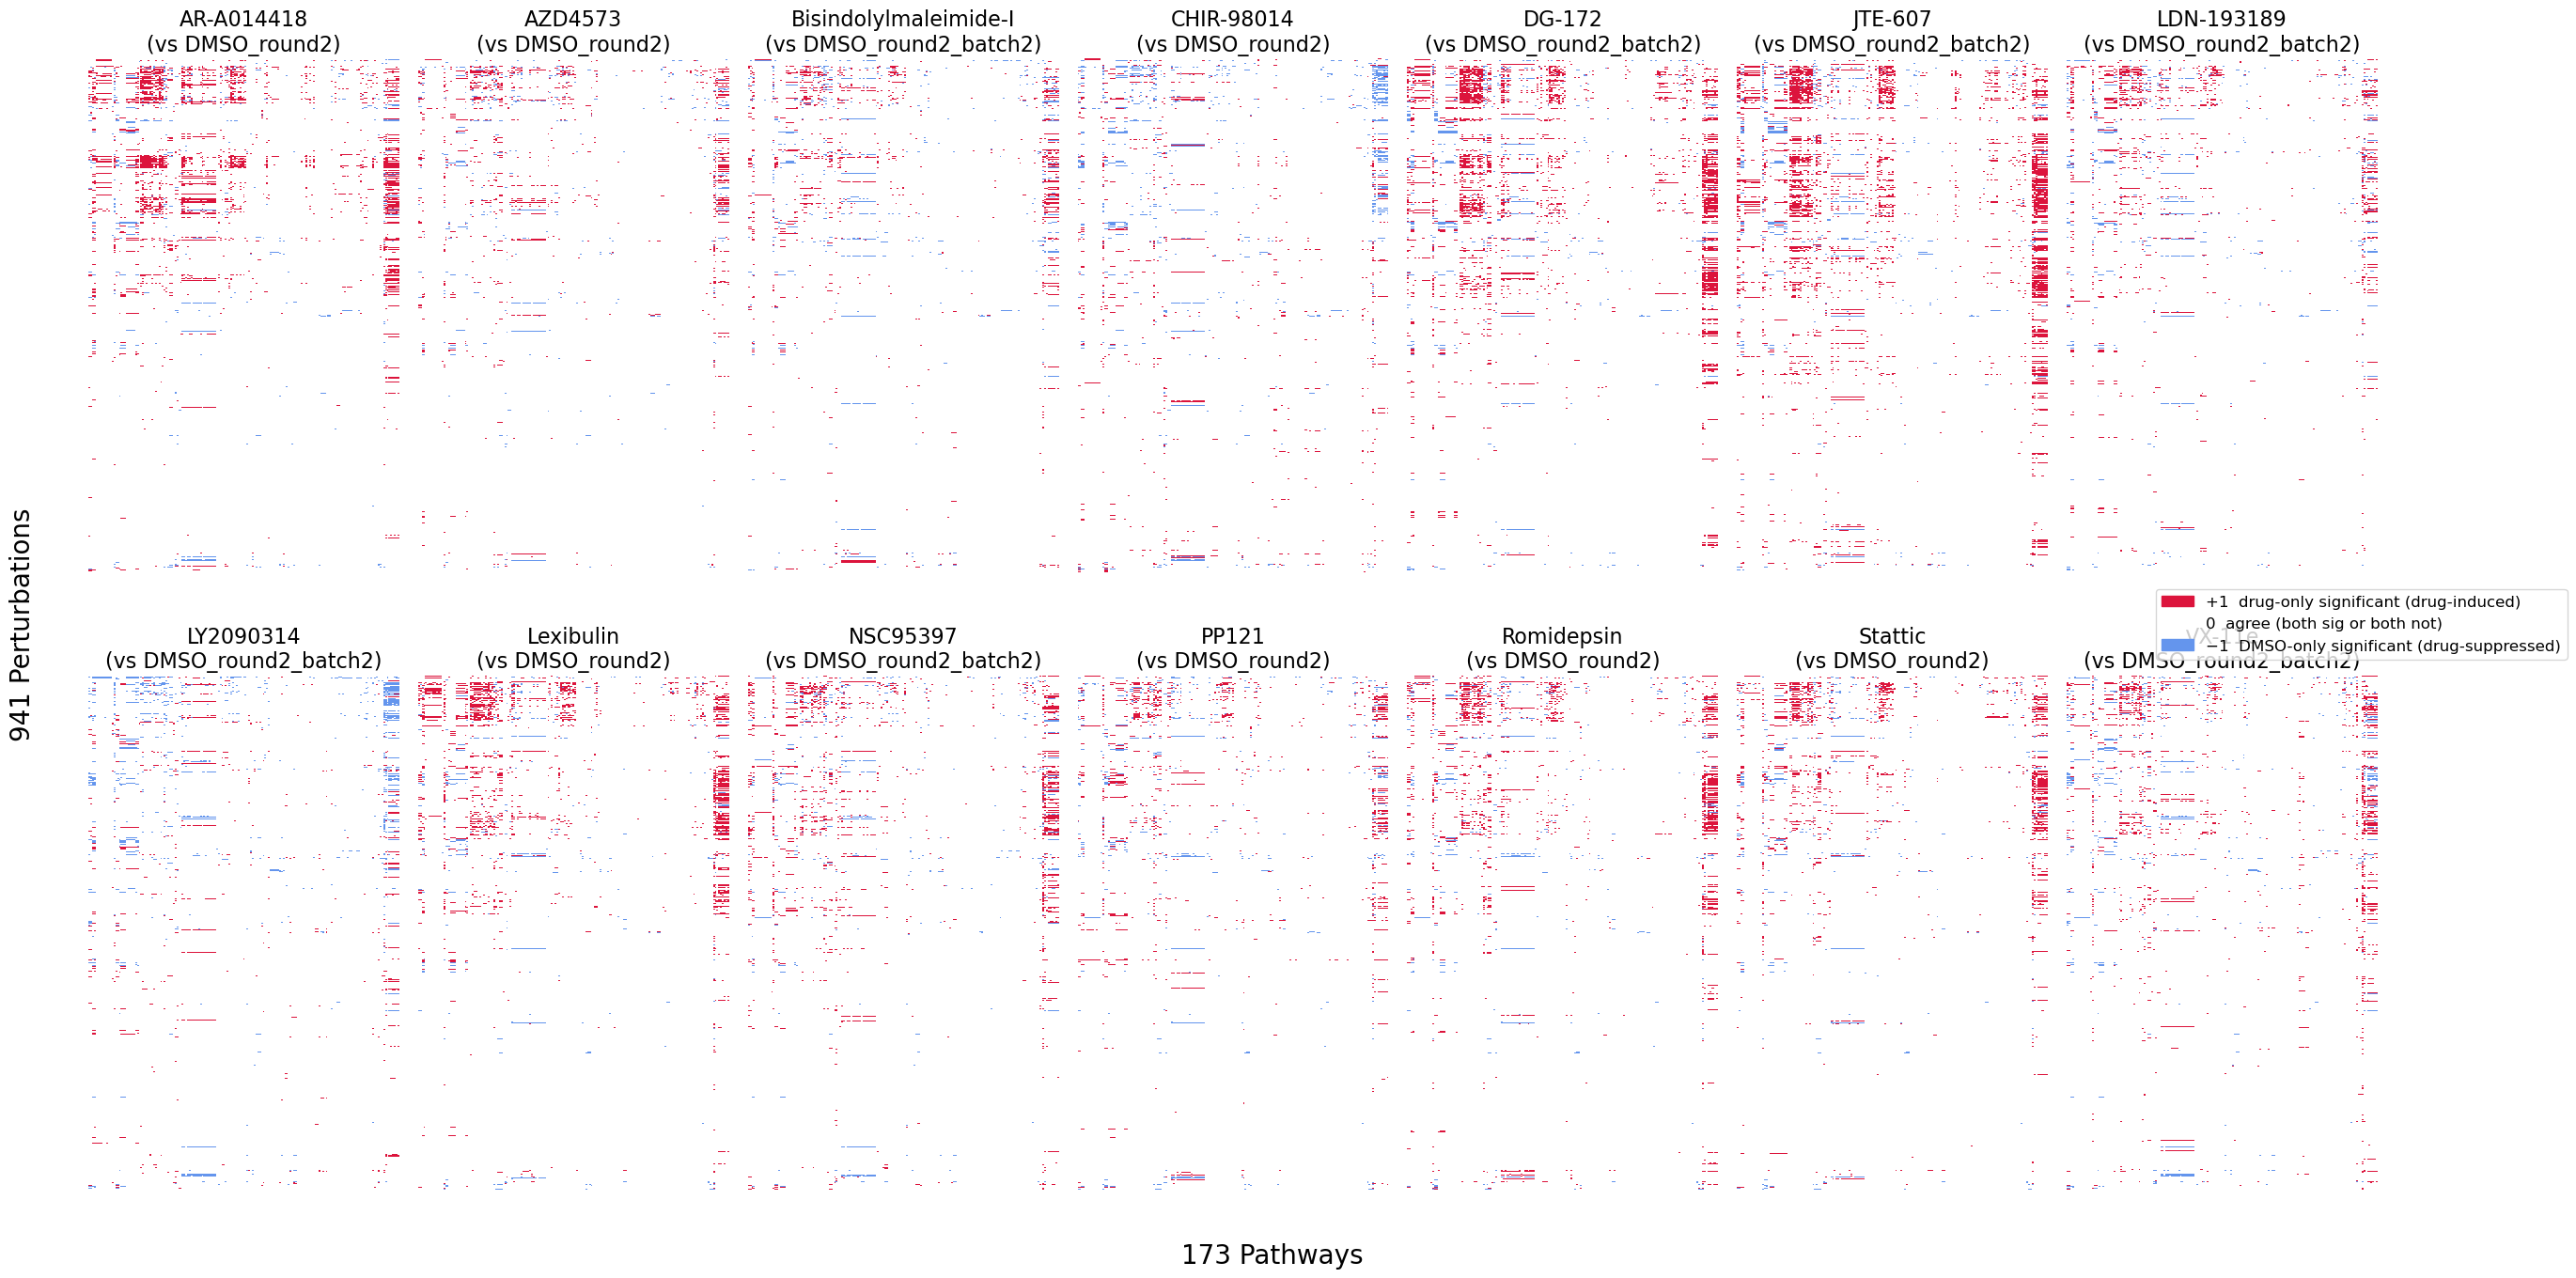

In [14]:
# Drug → batch lookup, mirroring TextFiles/SampleSheet.csv (Round2 only)
BATCH_DRUGS = {
    'batch1': ['AR-A014418', 'AZD4573', 'CHIR-98014', 'Lexibulin', 'PP121',
               'Romidepsin', 'Stattic', 'DMSO_round2'],
    'batch2': ['Bisindolylmaleimide-I', 'DG-172', 'JTE-607', 'LDN-193189',
               'LY2090314', 'NSC95397', 'VX-11e', 'DMSO_round2_batch2'],
}
DMSO_OF_BATCH = {'batch1': 'DMSO_round2', 'batch2': 'DMSO_round2_batch2'}
BATCH_OF_DRUG = {d: b for b, ds in BATCH_DRUGS.items() for d in ds}

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Binarised significance tensor
sig_bin = (q_value < Q_THRESHOLD).astype(np.int8)         # (D, P, K)

# Reuse same active filter (g_keep_perts_idx, g_keep_paths_idx, ordered_perts/paths)
# computed by the previous '2x8 grid' cell.
non_dmso_drugs = [d for d in drugs if d not in DMSO_OF_BATCH.values()]

diff_cmap = ListedColormap(['cornflowerblue', 'white', 'crimson'])  # for −1, 0, +1

fig, axes = plt.subplots(2, 7, figsize=(28, 14))
fig.subplots_adjust(left=0.05, right=0.92, top=0.93, bottom=0.07,
                    wspace=0.06, hspace=0.20)

for ax, drug in zip(axes.flat, non_dmso_drugs):
    d_idx     = drugs.index(drug)
    batch     = BATCH_OF_DRUG[drug]
    dmso_drug = DMSO_OF_BATCH[batch]
    dmso_idx  = drugs.index(dmso_drug)

    drug_sig = sig_bin[d_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)]
    dmso_sig = sig_bin[dmso_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)]
    diff     = drug_sig.astype(np.int8) - dmso_sig.astype(np.int8)   # ∈ {−1, 0, +1}

    diff_df = pd.DataFrame(
        diff,
        index=[perts[i]    for i in g_keep_perts_idx],
        columns=[pathways[j] for j in g_keep_paths_idx],
    ).loc[ordered_perts, ordered_paths]

    sns.heatmap(
        diff_df, ax=ax, cmap=diff_cmap, vmin=-1, vmax=1, center=0,
        cbar=False, xticklabels=False, yticklabels=False,
    )
    ax.set_title(f'{drug}\n(vs {dmso_drug})', fontsize=16)

fig.supxlabel(f'{len(ordered_paths):,} Pathways',     fontsize=20)
fig.supylabel(f'{len(ordered_perts):,} Perturbations', fontsize=20)

fig.legend(
    handles=[
        Patch(color='crimson',          label='+1  drug-only significant (drug-induced)'),
        Patch(color='white', edgecolor='gray', label='0  agree (both sig or both not)'),
        Patch(color='cornflowerblue',    label='−1  DMSO-only significant (drug-suppressed)'),
    ],
    loc='center right', bbox_to_anchor=(0.995, 0.5), fontsize=12,
)
plt.show()

## Drug-suppressed pathway activations  (the blue cells, per drug)

A `−1` cell means: that perturbation drove the pathway significant **under DMSO**, but under this drug the effect is gone. So per drug, the count of `−1` cells per pathway tells us how many KO perturbations had their pathway-activation **suppressed** by the drug.

Visualised as `(drug × pathway)` heatmap of suppression counts. Darker = more KOs lost their DMSO activation for that pathway under this drug — strong candidates for drug-modulated pathway dependencies.

Showing 32 pathways:
  top-30 by suppression count: 30
  curated BIO_INTEREST present in data:    5
  curated NOT already in top-30:        2
  added: ['KEGG_WNT_SIGNALING_PATHWAY', 'KEGG_MAPK_SIGNALING_PATHWAY']
  WARN: BIO_INTEREST not present in filtered data: ['KEGG_HEDGEHOG_SIGNALING_PATHWAY', 'KEGG_INSULIN_SIGNALING_PATHWAY', 'KEGG_JAK_STAT_SIGNALING_PATHWAY', 'KEGG_TGF_BETA_SIGNALING_PATHWAY', 'KEGG_PPAR_SIGNALING_PATHWAY', 'KEGG_NOTCH_SIGNALING_PATHWAY', 'KEGG_APOPTOSIS', 'KEGG_RIBOSOME', 'KEGG_RIBOSOME_BIOGENESIS_IN_EUKARYOTES']


/tmp/ipykernel_272788/1489980682.py:82: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


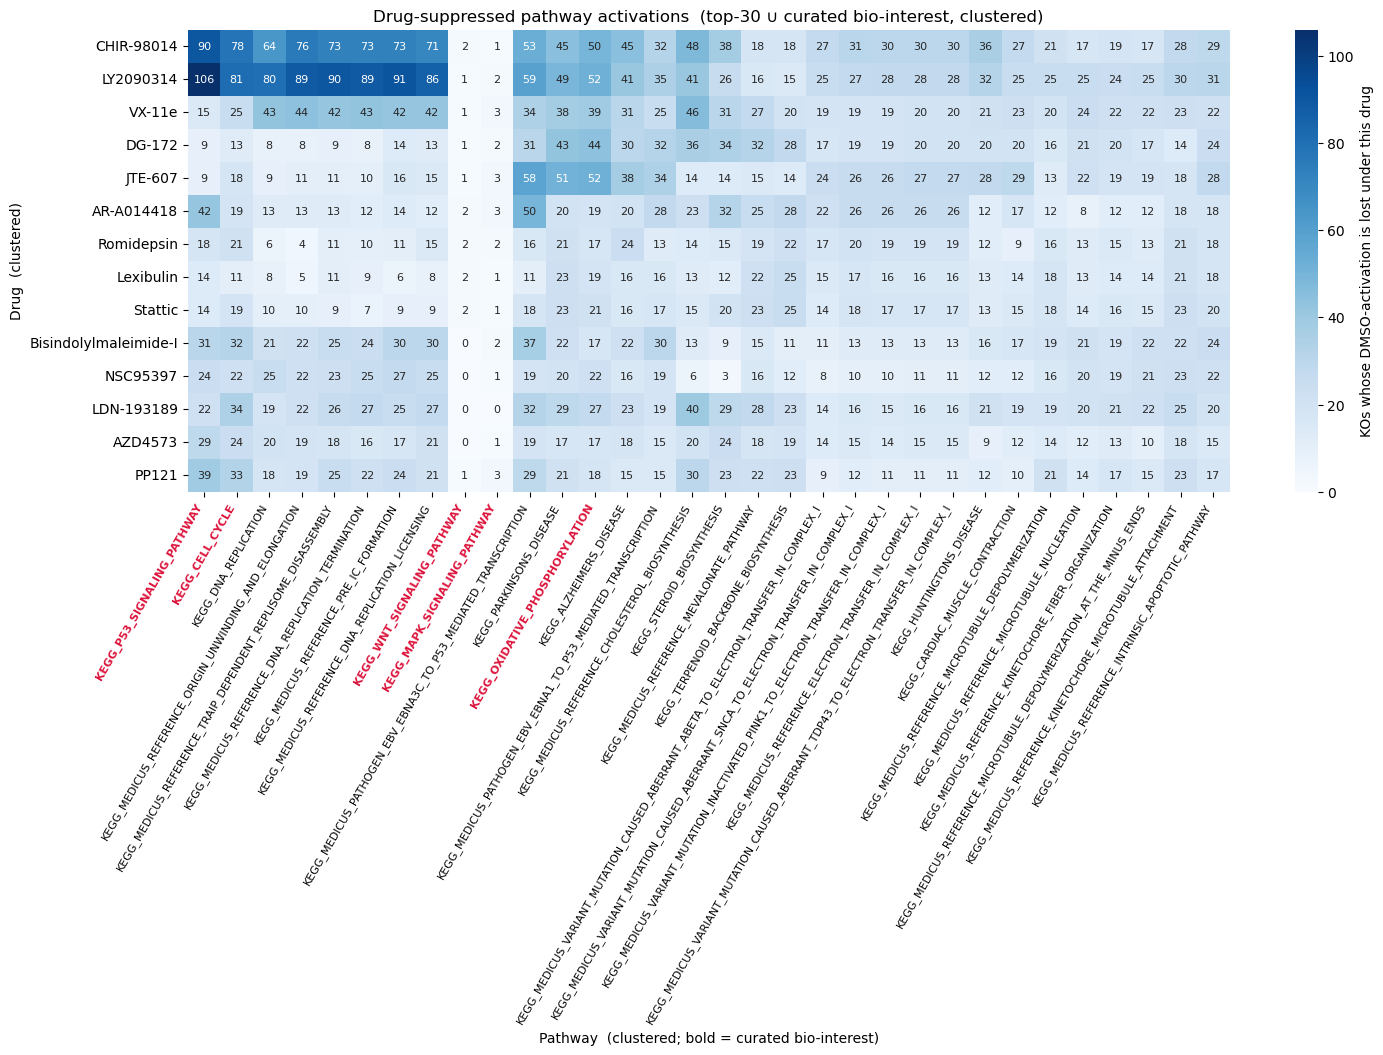


Top-10 drug-suppressed pathways per drug  (DMSO=sig, drug=not-sig):

--- AR-A014418                     (batch=batch1) ---
     50  KEGG_MEDICUS_PATHOGEN_EBV_EBNA3C_TO_P53_MEDIATED_TRANSCRIPTION
     42  KEGG_P53_SIGNALING_PATHWAY ★
     32  KEGG_STEROID_BIOSYNTHESIS
     28  KEGG_MEDICUS_PATHOGEN_EBV_EBNA1_TO_P53_MEDIATED_TRANSCRIPTION
     28  KEGG_TERPENOID_BACKBONE_BIOSYNTHESIS
     26  KEGG_MEDICUS_REFERENCE_ELECTRON_TRANSFER_IN_COMPLEX_I
     26  KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_PINK1_TO_ELECTRON_TRANSFER_IN_COMPLEX_I
     26  KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_TDP43_TO_ELECTRON_TRANSFER_IN_COMPLEX_I
     26  KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_SNCA_TO_ELECTRON_TRANSFER_IN_COMPLEX_I
     25  KEGG_MEDICUS_REFERENCE_MEVALONATE_PATHWAY

--- AZD4573                        (batch=batch1) ---
     29  KEGG_P53_SIGNALING_PATHWAY ★
     24  KEGG_CELL_CYCLE ★
     24  KEGG_STEROID_BIOSYNTHESIS
     21  KEGG_MEDICUS_REFERENCE_DNA_REPLICATION_LICENSING
     20

In [15]:
# Per (drug, pathway): count of perts where DMSO=sig and drug=not-sig (i.e. diff = −1)
# Reuses sig_bin, BATCH_OF_DRUG, DMSO_OF_BATCH, g_keep_perts_idx, g_keep_paths_idx, non_dmso_drugs from above.

# Curated pathways with mechanistic interest given the drug panel — always shown
# alongside the top-N most-affected pathways so we can see whether the biology we
# expect (Wnt for GSK-3 inhibitors, MAPK for VX-11e, p53/cell-cycle for Romidepsin
# and CDK9i, etc.) actually shows up.
BIO_INTEREST_PATHWAYS = [
    'KEGG_WNT_SIGNALING_PATHWAY',
    'KEGG_HEDGEHOG_SIGNALING_PATHWAY',
    'KEGG_INSULIN_SIGNALING_PATHWAY',
    'KEGG_MAPK_SIGNALING_PATHWAY',
    'KEGG_JAK_STAT_SIGNALING_PATHWAY',
    'KEGG_TGF_BETA_SIGNALING_PATHWAY',
    'KEGG_PPAR_SIGNALING_PATHWAY',
    'KEGG_NOTCH_SIGNALING_PATHWAY',
    'KEGG_CELL_CYCLE',
    'KEGG_P53_SIGNALING_PATHWAY',
    'KEGG_APOPTOSIS',
    'KEGG_OXIDATIVE_PHOSPHORYLATION',
    'KEGG_RIBOSOME',
    'KEGG_RIBOSOME_BIOGENESIS_IN_EUKARYOTES',
]

rows = []
for drug in non_dmso_drugs:
    d_idx     = drugs.index(drug)
    dmso_drug = DMSO_OF_BATCH[BATCH_OF_DRUG[drug]]
    dmso_idx  = drugs.index(dmso_drug)
    drug_sig = sig_bin[d_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)]
    dmso_sig = sig_bin[dmso_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)]
    suppressed = ((dmso_sig == 1) & (drug_sig == 0))
    rows.append(suppressed.sum(axis=0))

suppress_df = pd.DataFrame(
    rows,
    index=non_dmso_drugs,
    columns=[pathways[j] for j in g_keep_paths_idx],
)
col_order   = suppress_df.sum(axis=0).sort_values(ascending=False).index
suppress_df = suppress_df.loc[:, col_order]

# Build the visualised pathway set: union of (top-N by suppression) + (BIO_INTEREST present in data)
TOP_PATHWAYS = 30
top_by_count = list(col_order[:TOP_PATHWAYS])
bio_in_data  = [p for p in BIO_INTEREST_PATHWAYS if p in suppress_df.columns]
extra_bio    = [p for p in bio_in_data if p not in top_by_count]
shown_paths  = top_by_count + extra_bio                    # preserves count-rank for top-N
show_df      = suppress_df.loc[:, shown_paths]

print(f'Showing {len(shown_paths)} pathways:')
print(f'  top-{TOP_PATHWAYS} by suppression count: {len(top_by_count)}')
print(f'  curated BIO_INTEREST present in data:    {len(bio_in_data)}')
print(f'  curated NOT already in top-{TOP_PATHWAYS}:        {len(extra_bio)}')
if extra_bio:
    print(f'  added: {extra_bio}')
missing_bio = [p for p in BIO_INTEREST_PATHWAYS if p not in suppress_df.columns]
if missing_bio:
    print(f'  WARN: BIO_INTEREST not present in filtered data: {missing_bio}')

# Hierarchically cluster rows + columns of the shown slice
row_clust = cluster_order(np.nan_to_num(show_df.values,   nan=0.0))
col_clust = cluster_order(np.nan_to_num(show_df.values.T, nan=0.0))
show_df   = show_df.iloc[row_clust, col_clust]

fig, ax = plt.subplots(figsize=(max(10, 0.40 * len(shown_paths) + 4), 6))
sns.heatmap(
    show_df, ax=ax, cmap='Blues',
    annot=True, fmt='d', annot_kws={'size': 8},
    cbar_kws={'label': 'KOs whose DMSO-activation is lost under this drug'},
)
ax.set_title(f'Drug-suppressed pathway activations  (top-{TOP_PATHWAYS} \u222a curated bio-interest, clustered)')
ax.set_xlabel('Pathway  (clustered; bold = curated bio-interest)')
ax.set_ylabel('Drug  (clustered)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right', fontsize=8)
# Bold the curated bio-interest pathway tick labels
bio_set = set(BIO_INTEREST_PATHWAYS)
for t in ax.get_xticklabels():
    if t.get_text() in bio_set:
        t.set_fontweight('bold')
        t.set_color('crimson')
plt.tight_layout()
plt.show()

# Top-K suppressed pathways per drug — text view (uses unclustered suppress_df ordering)
K = 10
print(f'\nTop-{K} drug-suppressed pathways per drug  (DMSO=sig, drug=not-sig):\n')
for drug in non_dmso_drugs:
    top = suppress_df.loc[drug].sort_values(ascending=False).head(K)
    top = top[top > 0]
    print(f'--- {drug:30s} (batch={BATCH_OF_DRUG[drug]}) ---')
    if len(top) == 0:
        print('   (none — no suppression detected)')
    else:
        for pname, cnt in top.items():
            marker = ' \u2605' if pname in bio_set else ''
            print(f'   {int(cnt):>4d}  {pname}{marker}')
    print()

## Drug-induced pathway activations  (the red cells, per drug)

Mirror of the suppression heatmap above. A `+1` cell means: that perturbation was **not** significant for the pathway under DMSO, but **becomes** significant under this drug — the drug *induces* a pathway activity that wasn't there at baseline.

Per `(drug, pathway)`, the count is `# perts where DMSO=not-sig AND drug=sig`. Top-30 most-induced pathways shown. Rows + columns hierarchically clustered.

Together with the suppression heatmap above, this lets you see — for the same perturbations — which pathways are differentially **activated** vs **deactivated** across drug contexts.

Showing 32 pathways:
  top-30 by induction count: 30
  curated BIO_INTEREST in data:        5
  curated NOT already in top-30:    2
  added: ['KEGG_WNT_SIGNALING_PATHWAY', 'KEGG_MAPK_SIGNALING_PATHWAY']


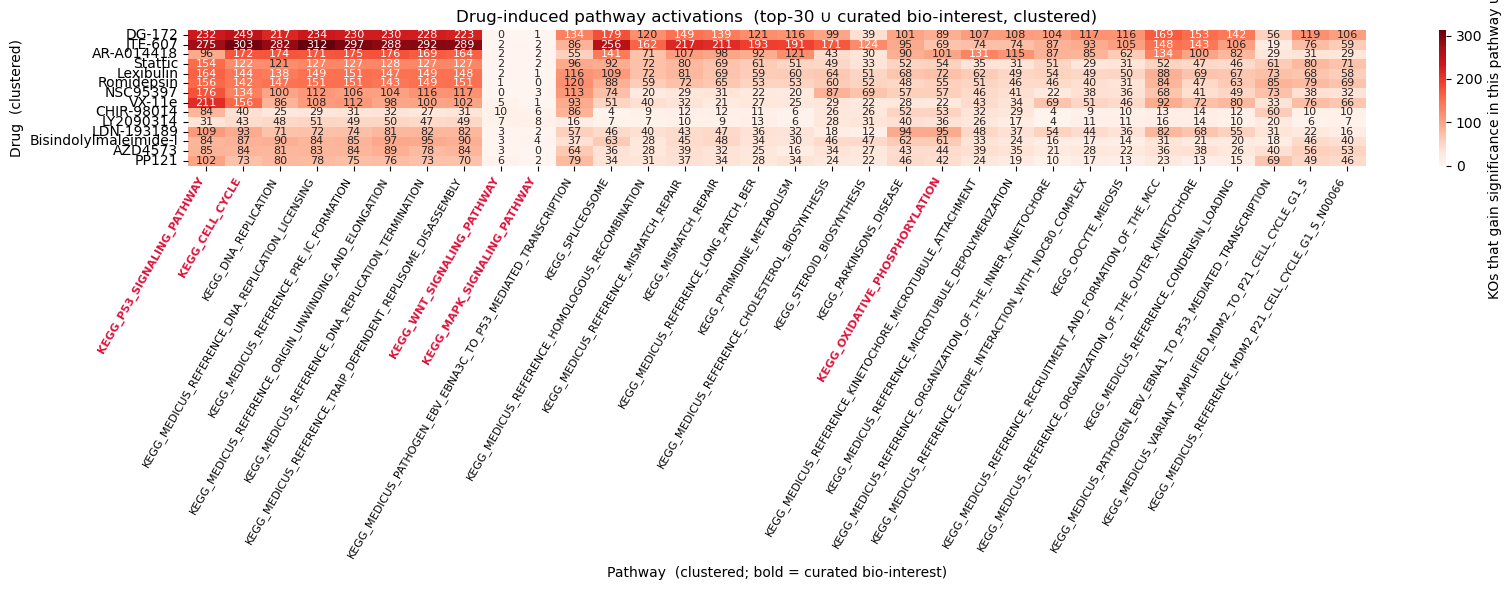


Top-10 drug-induced pathways per drug  (DMSO=not-sig, drug=sig):

--- AR-A014418                     (batch=batch1) ---
    176  KEGG_MEDICUS_REFERENCE_ORIGIN_UNWINDING_AND_ELONGATION
    175  KEGG_MEDICUS_REFERENCE_PRE_IC_FORMATION
    174  KEGG_DNA_REPLICATION
    172  KEGG_CELL_CYCLE ★
    171  KEGG_MEDICUS_REFERENCE_DNA_REPLICATION_LICENSING
    169  KEGG_MEDICUS_REFERENCE_DNA_REPLICATION_TERMINATION
    164  KEGG_MEDICUS_REFERENCE_TRAIP_DEPENDENT_REPLISOME_DISASSEMBLY
    141  KEGG_SPLICEOSOME
    134  KEGG_MEDICUS_REFERENCE_RECRUITMENT_AND_FORMATION_OF_THE_MCC
    131  KEGG_MEDICUS_REFERENCE_KINETOCHORE_MICROTUBULE_ATTACHMENT

--- AZD4573                        (batch=batch1) ---
     89  KEGG_MEDICUS_REFERENCE_ORIGIN_UNWINDING_AND_ELONGATION
     85  KEGG_P53_SIGNALING_PATHWAY ★
     84  KEGG_CELL_CYCLE ★
     84  KEGG_MEDICUS_REFERENCE_PRE_IC_FORMATION
     84  KEGG_MEDICUS_REFERENCE_TRAIP_DEPENDENT_REPLISOME_DISASSEMBLY
     83  KEGG_MEDICUS_REFERENCE_DNA_REPLICATION_LICENSIN

In [16]:
# Per (drug, pathway): count of perts where DMSO=not-sig AND drug=sig (i.e. diff = +1)
# BIO_INTEREST_PATHWAYS defined in the suppression cell above and reused here.

rows_ind = []
for drug in non_dmso_drugs:
    d_idx     = drugs.index(drug)
    dmso_drug = DMSO_OF_BATCH[BATCH_OF_DRUG[drug]]
    dmso_idx  = drugs.index(dmso_drug)
    drug_sig = sig_bin[d_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)]
    dmso_sig = sig_bin[dmso_idx][np.ix_(g_keep_perts_idx, g_keep_paths_idx)]
    induced  = ((dmso_sig == 0) & (drug_sig == 1))
    rows_ind.append(induced.sum(axis=0))

induce_df = pd.DataFrame(
    rows_ind,
    index=non_dmso_drugs,
    columns=[pathways[j] for j in g_keep_paths_idx],
)
induce_col_order = induce_df.sum(axis=0).sort_values(ascending=False).index
induce_df        = induce_df.loc[:, induce_col_order]

# Top-N by induction count + any curated bio-interest pathways present in data
TOP_PATHWAYS = 30
top_by_count = list(induce_col_order[:TOP_PATHWAYS])
bio_in_data  = [p for p in BIO_INTEREST_PATHWAYS if p in induce_df.columns]
extra_bio    = [p for p in bio_in_data if p not in top_by_count]
shown_paths  = top_by_count + extra_bio
show_ind     = induce_df.loc[:, shown_paths]

print(f'Showing {len(shown_paths)} pathways:')
print(f'  top-{TOP_PATHWAYS} by induction count: {len(top_by_count)}')
print(f'  curated BIO_INTEREST in data:        {len(bio_in_data)}')
print(f'  curated NOT already in top-{TOP_PATHWAYS}:    {len(extra_bio)}')
if extra_bio:
    print(f'  added: {extra_bio}')

row_clust = cluster_order(np.nan_to_num(show_ind.values,   nan=0.0))
col_clust = cluster_order(np.nan_to_num(show_ind.values.T, nan=0.0))
show_ind  = show_ind.iloc[row_clust, col_clust]

fig, ax = plt.subplots(figsize=(max(10, 0.40 * len(shown_paths) + 4), 6))
sns.heatmap(
    show_ind, ax=ax, cmap='Reds',
    annot=True, fmt='d', annot_kws={'size': 8},
    cbar_kws={'label': 'KOs that gain significance in this pathway under this drug'},
)
ax.set_title(f'Drug-induced pathway activations  (top-{TOP_PATHWAYS} \u222a curated bio-interest, clustered)')
ax.set_xlabel('Pathway  (clustered; bold = curated bio-interest)')
ax.set_ylabel('Drug  (clustered)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right', fontsize=8)
bio_set = set(BIO_INTEREST_PATHWAYS)
for t in ax.get_xticklabels():
    if t.get_text() in bio_set:
        t.set_fontweight('bold')
        t.set_color('crimson')
plt.tight_layout()
plt.show()

# Top-K induced pathways per drug — text view
K = 10
print(f'\nTop-{K} drug-induced pathways per drug  (DMSO=not-sig, drug=sig):\n')
for drug in non_dmso_drugs:
    top = induce_df.loc[drug].sort_values(ascending=False).head(K)
    top = top[top > 0]
    print(f'--- {drug:30s} (batch={BATCH_OF_DRUG[drug]}) ---')
    if len(top) == 0:
        print('   (none \u2014 no induction detected)')
    else:
        for pname, cnt in top.items():
            marker = ' \u2605' if pname in bio_set else ''
            print(f'   {int(cnt):>4d}  {pname}{marker}')
    print()

## Subset binary-difference grid: top-30 suppressed pathways × top-100 most-affected perts

Same per-drug `{−1, 0, +1}` colour code as the big grid above, but restricted to:

- **Columns**: the 30 most drug-suppressed pathways (the same `col_order[:30]` from the heatmap above)
- **Rows**: the 100 perturbations with the highest total `|diff|` count across these 30 pathways and all 14 drugs — i.e. perts whose enrichment in these pathways is most drug-context-dependent

Rows + columns are clustered once on the cross-drug mean diff so all 14 panels share axes.

Selected top-100 perts (|diff| score: 101..198) across 30 suppressed pathways


/tmp/ipykernel_272788/4172637090.py:66: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color='white', edgecolor='gray', label='0  agree'),


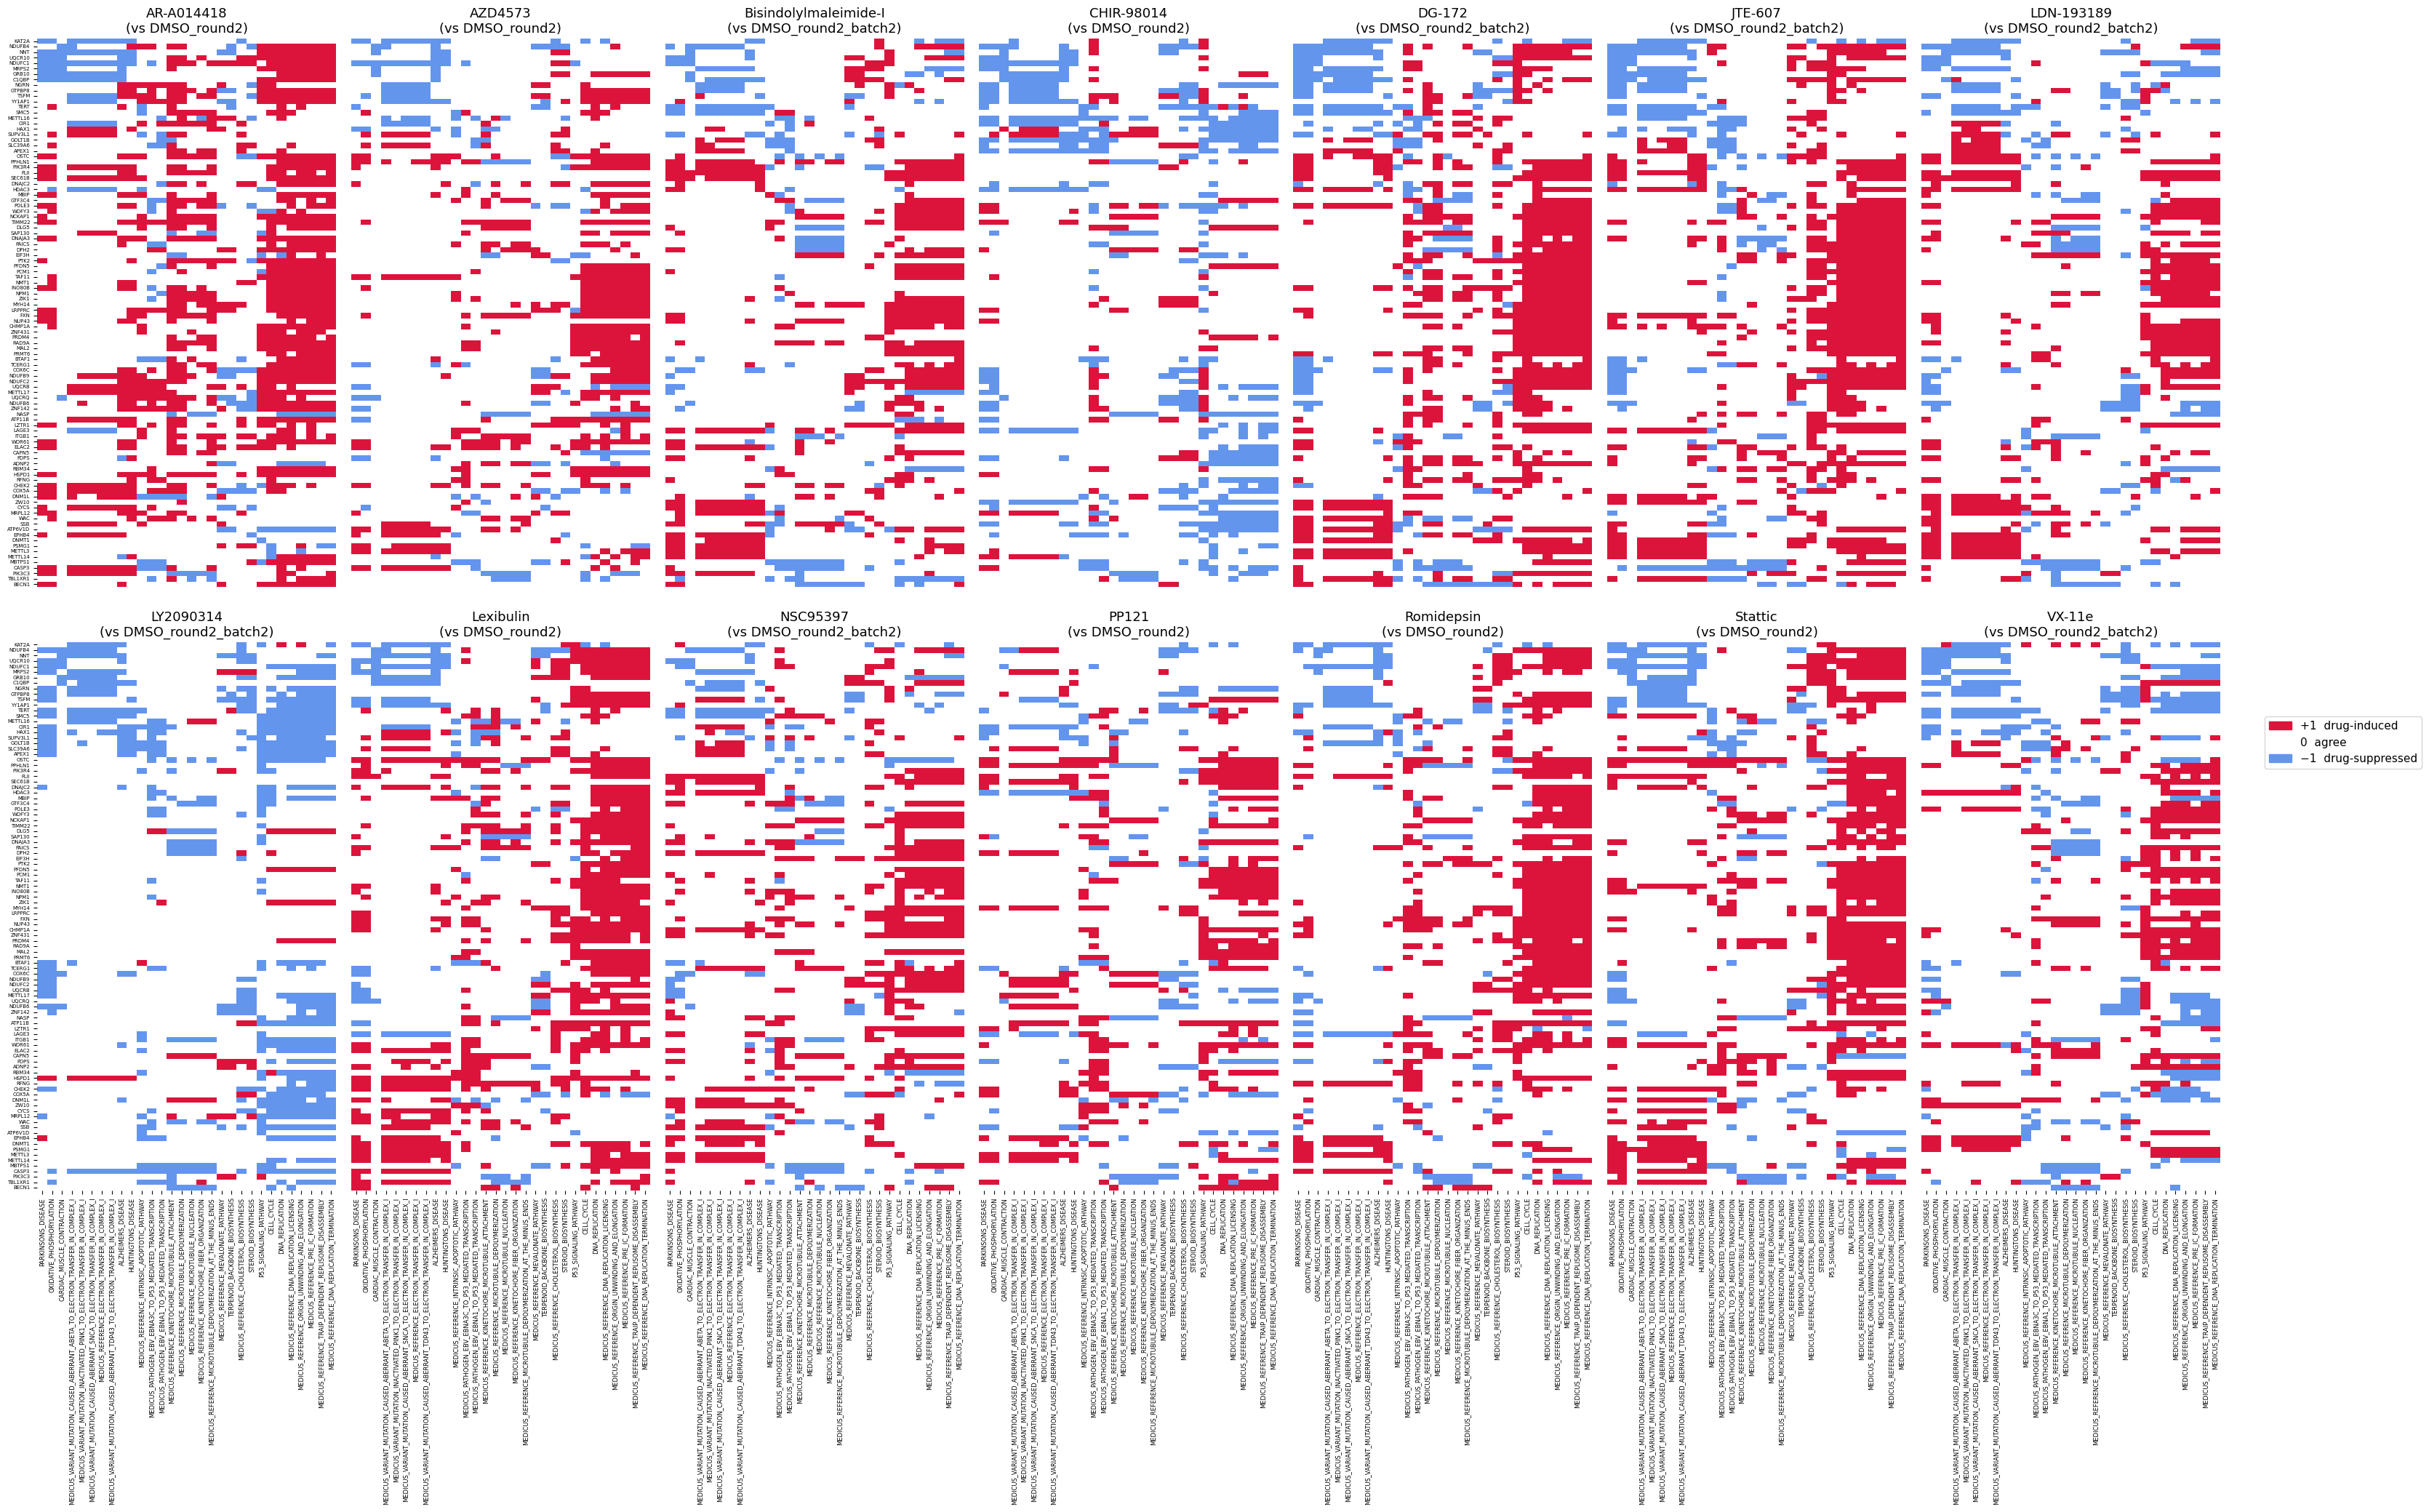

In [17]:
TOP_PATHWAYS = 30
TOP_PERTS    = 100

# (a) Pathway subset: top-30 most-suppressed (col_order is full pathway-name index from the previous cell)
top_pathway_names = list(col_order[:TOP_PATHWAYS])
top_path_pos      = [pathways.index(p) for p in top_pathway_names]   # indices into the full 568-pathway axis

# (b) Build mini diff tensor (n_drugs_nondmso, n_perts_kept, TOP_PATHWAYS) and rank perts by total |diff|
n_drugs_nd   = len(non_dmso_drugs)
n_perts_kept = len(g_keep_perts_idx)
diff_mini = np.zeros((n_drugs_nd, n_perts_kept, TOP_PATHWAYS), dtype=np.int8)

for d_pos, drug in enumerate(non_dmso_drugs):
    d_idx    = drugs.index(drug)
    dmso_idx = drugs.index(DMSO_OF_BATCH[BATCH_OF_DRUG[drug]])
    drug_sig = sig_bin[d_idx][np.ix_(g_keep_perts_idx, top_path_pos)]
    dmso_sig = sig_bin[dmso_idx][np.ix_(g_keep_perts_idx, top_path_pos)]
    diff_mini[d_pos] = drug_sig.astype(np.int8) - dmso_sig.astype(np.int8)

pert_score     = np.abs(diff_mini).sum(axis=(0, 2))                          # (n_perts_kept,)
top_pert_pos   = np.argsort(pert_score)[::-1][:TOP_PERTS]
top_pert_names = [perts[g_keep_perts_idx[i]] for i in top_pert_pos]

print(f'Selected top-{TOP_PERTS} perts (|diff| score: '
      f'{pert_score[top_pert_pos].min()}..{pert_score[top_pert_pos].max()}) '
      f'across {TOP_PATHWAYS} suppressed pathways')

# (c) Cluster perts + pathways on cross-drug mean diff so panels share axes
diff_mini_top = diff_mini[:, top_pert_pos, :]                                # (n_drugs_nd, TOP_PERTS, TOP_PATHWAYS)
mean_diff     = diff_mini_top.mean(axis=0).astype(float)
pert_order    = cluster_order(mean_diff)
path_order    = cluster_order(mean_diff.T)

ordered_perts_short = [top_pert_names[i] for i in pert_order]
ordered_paths_short = [top_pathway_names[i].replace('KEGG_', '') for i in path_order]

# (d) Plot 2×7 grid with pert names on the LEFT-most panels of each row,
#     and pathway names on the BOTTOM row only.
fig, axes = plt.subplots(2, 7, figsize=(38, 22))
fig.subplots_adjust(left=0.13, right=0.92, top=0.94, bottom=0.22,
                    wspace=0.05, hspace=0.10)

for d_pos, drug in enumerate(non_dmso_drugs):
    row, col = d_pos // 7, d_pos % 7
    ax       = axes[row, col]
    panel    = diff_mini_top[d_pos][np.ix_(pert_order, path_order)]

    show_y = (col == 0)
    show_x = (row == 1)

    sns.heatmap(
        panel, ax=ax, cmap=diff_cmap, vmin=-1, vmax=1, center=0,
        cbar=False,
        xticklabels=ordered_paths_short if show_x else False,
        yticklabels=ordered_perts_short if show_y else False,
    )
    if show_x:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
    if show_y:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=5)
    ax.set_title(f'{drug}\n(vs {DMSO_OF_BATCH[BATCH_OF_DRUG[drug]]})', fontsize=13)

fig.legend(
    handles=[
        Patch(color='crimson',          label='+1  drug-induced'),
        Patch(color='white', edgecolor='gray', label='0  agree'),
        Patch(color='cornflowerblue',    label='−1  drug-suppressed'),
    ],
    loc='center right', bbox_to_anchor=(0.995, 0.5), fontsize=11,
)
plt.show()

## DMSO_round2 vs DMSO_round2_batch2 — pathway-set overlap

The two DMSO files are technical replicates (same vehicle, different batches),
so the set of "active KEGG pathways" should agree closely between them.
"Active in drug X" = pathway has ≥ `MIN_PERTS_PER_PATHWAY` significant perts
in that drug. We compare the two sets at multiple per-drug thresholds.

In [ ]:
def active_pathways(drug, threshold):
    """Pathways with ≥ threshold significant perturbations in this drug."""
    d_idx = drugs.index(drug)
    sig_count = (q_value[d_idx] < Q_THRESHOLD).sum(axis=0)   # (n_pathways,)
    return set(np.array(pathways)[sig_count >= threshold])

rows = []
for thr in (10, 25, 50, 100, 200):
    A = active_pathways('DMSO_round2',         thr)
    B = active_pathways('DMSO_round2_batch2',  thr)
    inter = A & B
    union = A | B
    rows.append({
        'threshold':     thr,
        '|round2|':      len(A),
        '|batch2|':      len(B),
        '|intersection|': len(inter),
        '|union|':       len(union),
        'jaccard_%':     100.0 * len(inter) / max(len(union), 1),
        '%_round2_in_batch2': 100.0 * len(inter) / max(len(A), 1),
        '%_batch2_in_round2': 100.0 * len(inter) / max(len(B), 1),
    })
overlap_df = pd.DataFrame(rows)
print(overlap_df.to_string(index=False, float_format='%.1f'))

# Show the discordant pathways at the current MIN_PERTS_PER_PATHWAY
A = active_pathways('DMSO_round2',         MIN_PERTS_PER_PATHWAY)
B = active_pathways('DMSO_round2_batch2',  MIN_PERTS_PER_PATHWAY)
print(f'\nAt MIN_PERTS_PER_PATHWAY = {MIN_PERTS_PER_PATHWAY}:')
print(f'  in round2 only ({len(A - B)}): ' + ', '.join(sorted(A - B)[:8]) +
      ('...' if len(A - B) > 8 else ''))
print(f'  in batch2 only ({len(B - A)}): ' + ', '.join(sorted(B - A)[:8]) +
      ('...' if len(B - A) > 8 else ''))

## Build a reduced tensor

Two filters applied to the full `(16 × 2447 × 568)` tensor:

1. **Pathway axis** — keep pathways enriched in **≥ `PATHWAY_MIN_PERTS = 25`
   perturbations in at least one drug context** (max across drugs).
2. **Perturbation axis** — keep perturbations that enrich **≥ `PERT_MIN_PATHWAYS = 5`
   of the kept pathways within at least one drug context** (max across drugs).
   Hits in other drugs are not required — a pert that's strongly active in
   one drug and silent in the rest still qualifies.

Saved as `PathwayORA/KEGG/KEGG_ORA_tensor_reduced.h5` with the same dataset
layout as the full tensor (`neg_log10_q`, `q_value`, `odds_ratio` plus axis
labels). This is the input the downstream interaction-model script reads.

In [ ]:
PATHWAY_MIN_PERTS = 25   # pathway kept if some drug enriches ≥ this many perts
PERT_MIN_PATHWAYS = 5    # pert kept if it hits ≥ this many reduced pathways in some single drug

# Boolean significance tensor: (n_drugs, n_perts, n_pathways)
sig = q_value < Q_THRESHOLD

# Pathway filter: max over drugs of per-(drug, pathway) sig-pert count
sig_perts_per_drug_pathway = sig.sum(axis=1)                          # (n_drugs, n_pathways)
pathway_max_perts_any_drug = sig_perts_per_drug_pathway.max(axis=0)   # (n_pathways,)
keep_path_mask = pathway_max_perts_any_drug >= PATHWAY_MIN_PERTS
keep_path_idx  = np.where(keep_path_mask)[0]

# Perturbation filter on the pathway-reduced tensor: keep a perturbation if
# it enriches ≥ PERT_MIN_PATHWAYS of the kept pathways within at least one
# single drug context (max-across-drugs ≥ threshold). Hits in other drugs
# are not required.
sig_red_paths = sig[:, :, keep_path_idx]                               # (n_drugs, n_perts, n_paths_red)
pert_paths_per_drug = sig_red_paths.sum(axis=2)                        # (n_drugs, n_perts)
pert_max_paths_in_some_drug = pert_paths_per_drug.max(axis=0)          # (n_perts,)
keep_pert_mask = pert_max_paths_in_some_drug >= PERT_MIN_PATHWAYS
keep_pert_idx  = np.where(keep_pert_mask)[0]

print(f'Kept pathways: {len(keep_path_idx):>4d} / {len(pathways)} '
      f'(pathway has ≥ {PATHWAY_MIN_PERTS} sig perts in some drug)')
print(f'Kept perts:    {len(keep_pert_idx):>4d} / {len(perts)} '
      f'(pert hits ≥ {PERT_MIN_PATHWAYS} reduced pathways in some single drug)')

# Slice the three score tensors (re-load odds_ratio since it was not loaded in `load`)
with h5py.File(H5_PATH, 'r') as h:
    odds_ratio_full = h['odds_ratio'][:]

neg_log10_q_red = neg_log10_q[:, keep_pert_idx, :][:, :, keep_path_idx]
q_value_red     = q_value[:,     keep_pert_idx, :][:, :, keep_path_idx]
odds_ratio_red  = odds_ratio_full[:, keep_pert_idx, :][:, :, keep_path_idx]
perts_red    = [perts[i]    for i in keep_pert_idx]
pathways_red = [pathways[j] for j in keep_path_idx]
print(f'Reduced tensor shape: {neg_log10_q_red.shape}  '
      f'({neg_log10_q_red.nbytes/1e6:.1f} MB)')

Reduced tensor shape: (16, 1378, 211)  (18.6 MB)


In [ ]:
REDUCED_H5 = PROJECT_DIR / 'PathwayORA' / 'KEGG' / 'KEGG_ORA_tensor_reduced.h5'

with h5py.File(REDUCED_H5, 'w') as h:
    h.create_dataset('neg_log10_q', data=neg_log10_q_red, compression='gzip', compression_opts=4)
    h.create_dataset('q_value',     data=q_value_red,     compression='gzip', compression_opts=4)
    h.create_dataset('odds_ratio',  data=odds_ratio_red,  compression='gzip', compression_opts=4)
    str_dt = h5py.string_dtype(encoding='utf-8')
    h.create_dataset('drugs',         data=np.array(drugs,        dtype=object), dtype=str_dt)
    h.create_dataset('perturbations', data=np.array(perts_red,    dtype=object), dtype=str_dt)
    h.create_dataset('pathways',      data=np.array(pathways_red, dtype=object), dtype=str_dt)
    h.attrs['fdr_threshold']        = Q_THRESHOLD
    h.attrs['pathway_min_perts']    = PATHWAY_MIN_PERTS
    h.attrs['pert_min_pathways']    = PERT_MIN_PATHWAYS
    h.attrs['source_tensor']        = str(H5_PATH)
print(f'Saved {REDUCED_H5}  ({REDUCED_H5.stat().st_size/1e6:.1f} MB)')

## Re-plot per-drug heatmaps from the reduced tensor

The reduced tensor's pathway and perturbation axes are already filtered, so
we drop the `active_submatrix` step and just cluster + render per drug. Same
clustered column order is used across drugs so columns line up across panels.

In [ ]:
# Shared column (pathway) order: cluster on the global mean over drugs of the reduced tensor
mean_score_red = np.nanmean(neg_log10_q_red, axis=0)              # (n_perts_red, n_paths_red)
shared_col_order = cluster_order(np.nan_to_num(mean_score_red, nan=0.0).T)


def plot_reduced_drug(drug, ax=None, vmax=VMAX):
    d_idx = drugs.index(drug)
    sub = pd.DataFrame(neg_log10_q_red[d_idx], index=perts_red, columns=pathways_red)
    sub = sub.iloc[:, shared_col_order]
    row_order = cluster_order(np.nan_to_num(sub.values, nan=0.0))
    sub = sub.iloc[row_order, :]
    if ax is None:
        fig, ax = plt.subplots(figsize=FIGSIZE)
    sns.heatmap(
        sub,
        ax=ax,
        cmap='magma_r',
        vmin=0, vmax=vmax,
        cbar_kws={'label': '-log10(q_bh)'},
        xticklabels=False,
        yticklabels=False,
    )
    ax.set_title(f'{drug}  —  {sub.shape[0]} perts × {sub.shape[1]} pathways')
    return ax, sub


# Per-drug large heatmaps
for drug in drugs:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    plot_reduced_drug(drug, ax=ax)
    plt.tight_layout()
    plt.show()

# 4 × 4 grid for cross-context comparison
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
for ax, drug in zip(axes.flat, drugs):
    plot_reduced_drug(drug, ax=ax)
plt.tight_layout()
plt.show()

## Pick top 50 most context-dependent pathways

Module-scoring all 211 pathways across 16.5M cells is expensive. To stay
within wall-time we'll score only the pathways most likely to show
drug-context interaction.

Per-pathway context-dependence score (computed on the reduced tensor):

$$\text{context\_score}[k] \;=\; \text{mean}_p \left( \text{var}_d \left( -\log_{10}(q_{bh})[d, p, k] \right) \right)$$

For each pathway *k*, take the cross-drug variance of `-log10(q_bh)` per
perturbation, then average over perturbations. High score = the same pert
hits the pathway with very different strength across drug contexts — which
is exactly the interaction the OLS model is meant to detect.

Saves
- `PathwayORA/KEGG/pathway_context_dependence.csv` — all 211 pathways with
  context score + diagnostic columns
- `PathwayORA/KEGG/top50_context_dependent_pathways.txt` — pathway names
  one per line, consumed by the parallel module-scoring script

In [ ]:
T = neg_log10_q_red                                                  # (16, 1378, 211)

# Primary metric: cross-drug variance per (pert, pathway), then mean over perts
pert_path_var_across_drugs = np.nanvar(T, axis=0)                    # (1378, 211)
context_score              = np.nanmean(pert_path_var_across_drugs, axis=0)  # (211,)

# Diagnostics
pert_path_range = np.nanmax(T, axis=0) - np.nanmin(T, axis=0)        # (1378, 211)
mean_range_across_drugs = np.nanmean(pert_path_range, axis=0)        # (211,)

sig_red = q_value_red < Q_THRESHOLD                                  # (16, 1378, 211)
sig_perts_per_drug_path  = sig_red.sum(axis=1)                       # (16, 211)
max_sig_perts_in_any_drug = sig_perts_per_drug_path.max(axis=0)
mean_sig_perts_per_drug   = sig_perts_per_drug_path.mean(axis=0)
n_drugs_with_5plus_sig    = (sig_perts_per_drug_path >= 5).sum(axis=0)

ctx_df = pd.DataFrame({
    'pathway':                    pathways_red,
    'context_score':              context_score,
    'mean_range_across_drugs':    mean_range_across_drugs,
    'max_sig_perts_in_any_drug':  max_sig_perts_in_any_drug,
    'mean_sig_perts_per_drug':    mean_sig_perts_per_drug,
    'n_drugs_with_5plus_sig':     n_drugs_with_5plus_sig,
}).sort_values('context_score', ascending=False).reset_index(drop=True)

print('Top 20 most context-dependent pathways:')
print(ctx_df.head(20).to_string())
print('\nBottom 5:')
print(ctx_df.tail(5).to_string())

# --- Save ------------------------------------------------------------------
TOP_N   = 50
out_csv = PROJECT_DIR / 'PathwayORA' / 'KEGG' / 'pathway_context_dependence.csv'
out_txt = PROJECT_DIR / 'PathwayORA' / 'KEGG' / f'top{TOP_N}_context_dependent_pathways.txt'

ctx_df.to_csv(out_csv, index=False)
top_pathways = ctx_df.head(TOP_N)['pathway'].tolist()
with open(out_txt, 'w') as f:
    f.write('\n'.join(top_pathways) + '\n')

print(f'\nSaved {out_csv}')
print(f'Saved {out_txt} ({TOP_N} pathways)')